# In-situ root image generation with Improved CycleGAN (Model 1) — minimal reproduction

Paper: **"In Situ Root Dataset Expansion Strategy Based on an Improved CycleGAN Generator"**, Plant Phenomics 6:0148 (2024), DOI [10.34133/plantphenomics.0148](https://doi.org/10.34133/plantphenomics.0148), PMCID PMC11020132.

Author code: https://github.com/jiwd123/improved_cyclegan (commit `bf8aa4112b77201474953590879d45164c98ccae`).
Weights & data: Zenodo record [10460303](https://doi.org/10.5281/zenodo.10460303) (CC-BY-4.0).

**Scope (partial demonstration).** This notebook reproduces the paper's *inference and postprocessing* stage on one example:
1. Load the released **Model 1** generator (improved CycleGAN generator: 4x downsampling, UNet skip connections with CBAM attention, subpixel/PixelShuffle upsampling; paper Fig. 4, `models1.py`).
2. Translate a 256×256 root **mask** into a textured root image (the paper's "blank-to-root" generation).
3. Apply the authors' background-separation postprocessing (`hcl.py`): unstable generated background pixels are set to white where the paired mask is black.
4. Show the input mask vs the generated root.

**Omitted:** CycleGAN training (200 epochs, RTX 3060), Model 0–7 FID/KID comparison, Improved_UNet segmentation evaluation on 2,227 images, timing benchmarks. A one-example run does not verify the paper's dataset-level claims.

Author code (`models1.py`, `cbam.py`) is embedded verbatim below; path-dependent scripts are adapted to Colab paths with the change noted beside the cell. All downloads and scientific execution run inside this notebook on Colab. Validated on a **CPU** Colab runtime (single-image inference; GPU works identically via the `DEVICE` switch).

**Cell 1: environment check.** Verify Python/PyTorch and select the compute device. Expected: PyTorch preinstalled on Colab; CPU is sufficient for this 256×256 single-image inference.

In [ ]:
import sys, torch, shutil, time
print(sys.version)
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print(shutil.disk_usage("/content"))

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
torch 2.11.0+cpu | cuda: False
device: cpu
usage(total=242486079488, used=21979430912, free=220489871360)


**Cell 2: download the released Model 1 weights and verify integrity.** `model.zip` (3.47 GB) from Zenodo record 10460303 contains the authors' checkpoints for Models 0–7 (`model1/netG_A2B.pth`, `model1/netG_B2A.pth`, discriminators, plus per-model test data). We verify the archive MD5 `839852695d6d9d08b5b70c984c601f2a` and confirm the `model1/` generator entries exist. Expected: `md5 verified` and the listed checkpoint names.

In [ ]:
import urllib.request, hashlib, zipfile, os, time
os.chdir("/content")
MODEL_ZIP = "model.zip"
MODEL_MD5 = "839852695d6d9d08b5b70c984c601f2a"
url = "https://zenodo.org/api/records/10460303/files/model.zip/content"
def md5sum(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 22), b""):
            h.update(chunk)
    return h.hexdigest()
if not os.path.exists(MODEL_ZIP) or md5sum(MODEL_ZIP) != MODEL_MD5:
    for attempt in range(3):
        try:
            t0 = time.time()
            urllib.request.urlretrieve(url, MODEL_ZIP)
            print("downloaded in %.1f s" % (time.time() - t0))
            break
        except Exception as e:
            print("attempt", attempt, "failed:", repr(e))
            time.sleep(10 * (attempt + 1))
assert md5sum(MODEL_ZIP) == MODEL_MD5, "MD5 mismatch"
print("md5 verified")
zsrc = zipfile.ZipFile(MODEL_ZIP)
for n in ["model1/netG_A2B.pth", "model1/netG_B2A.pth"]:
    print(n, zsrc.getinfo(n).file_size, "bytes")

downloaded in 482.7 s


md5 verified
model1/netG_A2B.pth 101691295 bytes
model1/netG_B2A.pth 101691295 bytes


**Cell 3: author generator code (verbatim).** Embed the authors' `models1.py` (Model 1 generator) and `cbam.py` (CBAM attention module) exactly as released at commit `bf8aa411`, and write them to `/content`. These files are copied byte-for-byte from the pinned commit; no architectural changes are made. Expected: two files written.

In [ ]:
AUTHOR_COMMIT = "bf8aa4112b77201474953590879d45164c98ccae"
with open("/content/cbam.py", "w") as f:
    f.write('import torch\nimport torch.nn as nn\nclass CBAMLayer(nn.Module):\n    def __init__(self, channel, reduction=16, spatial_kernel=7):\n        super(CBAMLayer, self).__init__()\n        # channel attention 压缩H,W为1\n        self.max_pool = nn.AdaptiveMaxPool2d(1)\n        self.avg_pool = nn.AdaptiveAvgPool2d(1)\n        # shared MLP\n        self.mlp = nn.Sequential(\n            # Conv2d比Linear方便操作\n            # nn.Linear(channel, channel // reduction, bias=False)\n            nn.Conv2d(channel, channel // reduction, 1, bias=False),\n            # inplace=True直接替换，节省内存\n            nn.ReLU(inplace=True),\n            # nn.Linear(channel // reduction, channel,bias=False)\n            nn.Conv2d(channel // reduction, channel, 1, bias=False)\n        )\n        # spatial attention\n        self.conv = nn.Conv2d(2, 1, kernel_size=spatial_kernel,\n                              padding=spatial_kernel // 2, bias=False)\n        self.sigmoid = nn.Sigmoid()\n    def forward(self, x):\n        max_out = self.mlp(self.max_pool(x))\n        avg_out = self.mlp(self.avg_pool(x))\n        channel_out = self.sigmoid(max_out + avg_out)\n        x = channel_out * x\n        max_out, _ = torch.max(x, dim=1, keepdim=True)\n        avg_out = torch.mean(x, dim=1, keepdim=True)\n        spatial_out = self.sigmoid(self.conv(torch.cat([max_out, avg_out], dim=1)))\n        x = spatial_out * x\n        return x\n')
with open("/content/models1.py", "w") as f:
    f.write('import torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom cbam import CBAMLayer\n\nclass ResidualBlock(nn.Module):\n    def __init__(self, in_features):\n        super(ResidualBlock, self).__init__()\n\n        conv_block = [  nn.ReflectionPad2d(1),\n                        nn.Conv2d(in_features, in_features, 3),\n                        nn.InstanceNorm2d(in_features),\n                        nn.LeakyReLU(0.01,inplace=True),\n                        nn.ReflectionPad2d(1),\n                        nn.Conv2d(in_features, in_features, 3),\n                        nn.InstanceNorm2d(in_features)  ]\n\n        self.conv_block = nn.Sequential(*conv_block)\n\n    def forward(self, x):\n        return x + self.conv_block(x)\n\nclass Generator(nn.Module):\n    def __init__(self, input_nc, output_nc):\n        super(Generator, self).__init__()\n\n        # Initial convolution block       \n        self.ICB = nn.Sequential(nn.ReflectionPad2d(3),\n                    nn.Conv2d(input_nc, 64, 7),\n                    nn.InstanceNorm2d(64),\n                    nn.ReLU(inplace=True))\n\n        # Downsampling\n        self.down1 = nn.Sequential(nn.Conv2d(64, 128, 3, stride=2, padding=1),\n                        nn.InstanceNorm2d(128),\n                        nn.ReLU(inplace=True))\n        self.down2 = nn.Sequential(nn.Conv2d(128, 256, 3, stride=2, padding=1),\n                        nn.InstanceNorm2d(256),\n                        nn.ReLU(inplace=True))\n        self.down3 = nn.Sequential(nn.Conv2d(256, 512, 3, stride=2, padding=1),\n                        nn.InstanceNorm2d(512),\n                        nn.ReLU(inplace=True))\n        self.down4 = nn.Sequential(nn.Conv2d(512, 1024, 3, stride=2, padding=1),\n                        nn.InstanceNorm2d(1024),\n                        nn.ReLU(inplace=True))\n\n        self.cbam1 = CBAMLayer(128)\n        self.cbam2 = CBAMLayer(256)\n        self.cbam3 = CBAMLayer(512)\n        self.cbam0 = CBAMLayer(64)\n\n        \n        # in_features = 64\n        # out_features = in_features*2\n        # for _ in range(2):\n        #     model += [  nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),\n        #                 nn.InstanceNorm2d(out_features),\n        #                 nn.ReLU(inplace=True) ]\n        #     in_features = out_features\n        #     out_features = in_features*2\n            \n\n        # Residual blocks\n        self.resblock = nn.Sequential(ResidualBlock(1024))\n        # for _ in range(n_residual_blocks):\n        #     model += [ResidualBlock(in_features)]\n\n        # Upsampling\n        self.PSblock1 = nn.Sequential(nn.PixelShuffle(2),\n                        nn.InstanceNorm2d(256),\n                        nn.ReLU(inplace=True))\n        self.PSblock2 = nn.Sequential(nn.PixelShuffle(2),\n                        nn.InstanceNorm2d(128),\n                        nn.ReLU(inplace=True))\n        self.PSblock3 = nn.Sequential(nn.PixelShuffle(2),\n                        nn.InstanceNorm2d(64),\n                        nn.ReLU(inplace=True))\n        self.PSblock4 = nn.Sequential(nn.PixelShuffle(2),\n                        nn.InstanceNorm2d(16),\n                        nn.ReLU(inplace=True))\n\n        # out_features = in_features//4\n        # for _ in range(2):\n        #     model += [  #nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),\n        #                 #nn.InstanceNorm2d(out_features),\n        #                 #nn.LeakyReLU(inplace=True)\n        #                 nn.PixelShuffle(2),\n        #                 nn.InstanceNorm2d(out_features),\n        #                 nn.ReLU(inplace=True)]\n        #     in_features = out_features\n        #     out_features = in_features//4\n\n        # Output layer\n        self.out = nn.Sequential(nn.ReflectionPad2d(3),\n                    nn.Conv2d(4, output_nc, 7),\n                    nn.Tanh())\n        # model += [  nn.ReflectionPad2d(3),\n        #             nn.Conv2d(16, output_nc, 7),\n        #             nn.Tanh() ]\n\n        #self.model = nn.Sequential(*model)\n        self.conv_cat1 = nn.Sequential(\n\t\t\t\tnn.Conv2d(768, 256, 1, 1, padding=0,bias=True),\n\t\t\t\tnn.InstanceNorm2d(256),\n\t\t\t\tnn.ReLU(inplace=True))\n        self.conv_cat2 = nn.Sequential(\n\t\t\t\tnn.Conv2d(320, 64, 1, 1, padding=0,bias=True),\n\t\t\t\tnn.InstanceNorm2d(64),\n\t\t\t\tnn.ReLU(inplace=True))\n        self.conv_cat3 = nn.Sequential(\n\t\t\t\tnn.Conv2d(144, 16, 1, 1, padding=0,bias=True),\n\t\t\t\tnn.InstanceNorm2d(16),\n\t\t\t\tnn.ReLU(inplace=True))\n        self.conv_cat4 = nn.Sequential(\n\t\t\t\tnn.Conv2d(68, 4, 1, 1, padding=0,bias=True),\n\t\t\t\tnn.InstanceNorm2d(4),\n\t\t\t\tnn.ReLU(inplace=True))\n\n\n\n    def forward(self, x):\n        x0 = self.ICB(x)\n        x1 = self.down1(x0)\n        x2 = self.down2(x1)\n        x3 = self.down3(x2)\n        x4 = self.down4(x3)\n        x = self.resblock(x4)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.resblock(x)\n        x = self.PSblock1(x)\n        x3 = self.cbam3(x3)\n        cat1 = torch.cat([x,x3],dim=1)\n        x = self.conv_cat1(cat1)\n        x = self.PSblock2(x)\n        x2 = self.cbam2(x2)\n        cat2 = torch.cat([x,x2],dim=1)\n        x = self.conv_cat2(cat2)\n        x = self.PSblock3(x)\n        x1 = self.cbam1(x1)\n        cat3 = torch.cat([x,x1],dim=1)\n        x = self.conv_cat3(cat3)\n        x = self.PSblock4(x)\n        x0 = self.cbam0(x0)\n        cat4 = torch.cat([x,x0],dim=1)\n        x = self.conv_cat4(cat4)\n        x = self.out(x)\n        \n            \n        return x\n\nclass Discriminator(nn.Module):\n    def __init__(self, input_nc):\n        super(Discriminator, self).__init__()\n\n        # A bunch of convolutions one after another\n        model = [   nn.Conv2d(input_nc, 64, 4, stride=2, padding=1),\n                    nn.LeakyReLU(0.2, inplace=True) ]\n\n        model += [  nn.Conv2d(64, 128, 4, stride=2, padding=1),\n                    nn.InstanceNorm2d(128), \n                    nn.LeakyReLU(0.2, inplace=True) ]\n\n        model += [  nn.Conv2d(128, 256, 4, stride=2, padding=1),\n                    nn.InstanceNorm2d(256), \n                    nn.LeakyReLU(0.2, inplace=True) ]\n\n        model += [  nn.Conv2d(256, 512, 4, padding=1),\n                    nn.InstanceNorm2d(512), \n                    nn.LeakyReLU(0.2, inplace=True) ]\n\n        # FCN classification layer\n        model += [nn.Conv2d(512, 1, 4, padding=1)]\n\n        self.model = nn.Sequential(*model)\n\n    def forward(self, x):\n        x =  self.model(x)\n        # Average pooling and flatten\n        return F.avg_pool2d(x, x.size()[2:]).view(x.size()[0], -1)')
print("wrote /content/cbam.py and /content/models1.py (verbatim from", AUTHOR_COMMIT + ")")

wrote /content/cbam.py and /content/models1.py (verbatim from bf8aa4112b77201474953590879d45164c98ccae)


**Cell 4: instantiate the Model 1 generator and load both released directions.** The authors' `test` script uses `input_nc = output_nc = 3`, size 256, and `ToTensor` + `Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))` preprocessing (verified against the script shipped in the Zenodo repo snapshot). The released archive contains both CycleGAN directions (`netG_A2B`, `netG_B2A`); the mapping direction (masks→roots) is resolved empirically in the next cell. Expected: both strict loads succeed.

In [ ]:
import torch, io
sd_A2B = torch.load(io.BytesIO(zsrc.read("model1/netG_A2B.pth")), map_location="cpu", weights_only=False)
sd_B2A = torch.load(io.BytesIO(zsrc.read("model1/netG_B2A.pth")), map_location="cpu", weights_only=False)
assert sd_A2B["ICB.1.weight"].shape == (64, 3, 7, 7) and sd_A2B["out.1.weight"].shape == (3, 4, 7, 7)
import sys
sys.path.insert(0, "/content")
from models1 import Generator
G_A2B = Generator(3, 3).to(DEVICE)
G_B2A = Generator(3, 3).to(DEVICE)
G_A2B.load_state_dict(sd_A2B, strict=True)
G_B2A.load_state_dict(sd_B2A, strict=True)
G_A2B.eval(); G_B2A.eval()
print("strict loads OK; generator params:", sum(p.numel() for p in G_A2B.parameters()))

strict loads OK; generator params: 25419195


**Cell 5: download an annotated example root mask.** Fetch `1-100ANN.zip` (46.7 MB; the authors' 100 expert-annotated in-situ root masks, MD5 `55665de1e1a07389d9ab23df1bd98589`) and extract the deterministic example `1-100/1.png`. Expected: verified archive and the extracted mask path printed.

In [ ]:
ANN_MD5 = "55665de1e1a07389d9ab23df1bd98589"
ann = "1-100ANN.zip"
def md5sum2(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 22), b""):
            h.update(chunk)
    return h.hexdigest()
if not os.path.exists(ann) or md5sum2(ann) != ANN_MD5:
    urllib.request.urlretrieve("https://zenodo.org/api/records/10460303/files/1-100ANN.zip/content", ann)
assert md5sum2(ann) == ANN_MD5
zann = zipfile.ZipFile(ann)
zann.extract("1-100/1.png", "/content/ann")
info = zann.getinfo("1-100/1.png")
print("extracted 1-100/1.png:", info.file_size, "bytes (compressed", info.compress_size, ")")

extracted 1-100/1.png: 637665 bytes (compressed 582638 )


**Cell 6: prepare the 256×256 mask tensor (authors' preprocessing).** Resize the annotation to 256×256 (the CycleGAN input size), binarize to the authors' convention (white root, black background), replicate to 3 channels, and normalize to `[-1, 1]` exactly as the authors' `datasets.py`/`test` script do. Expected: tensor shape `(1, 3, 256, 256)` in `[-1, 1]`.

In [ ]:
from PIL import Image
import numpy as np
import torchvision.transforms as T
img = Image.open("/content/ann/1-100/1.png").convert("L").resize((256, 256), Image.NEAREST)
a = np.array(img)
a = ((a > 127).astype(np.uint8) * 255)
Image.fromarray(a).save("/content/mask_256.png")
tf = T.Compose([T.ToTensor(), T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
x = tf(Image.fromarray(a).convert("RGB")).unsqueeze(0).to(DEVICE)
print("mask tensor:", tuple(x.shape), float(x.min()), float(x.max()))

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (143197800 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


mask tensor: (1, 3, 256, 256) -1.0 1.0


**Cell 7: generate the textured root (Model 1 inference, both directions).** Run each released generator on the mask. The CycleGAN was trained as an inverse pair, so exactly one direction maps masks→roots; the other produces a mask-like image. Following the paper's Model 1 selection (best FID 17.74 and highest subjective score), we select the direction whose output is genuinely textured, measured by the mean cross-channel standard deviation (root textures have distinct R/G/B; a mask prediction is near-gray). Expected: one direction selected with a clearly higher color variance.

In [ ]:
def color_variance(y):
    rgb = ((y[0].cpu().float().numpy().transpose(1, 2, 0) + 1.0) / 2.0 * 255.0)
    return float(rgb.std(axis=2).mean())
with torch.no_grad():
    y_A2B = G_A2B(x)
    y_B2A = G_B2A(x)
scores = {"netG_A2B": color_variance(y_A2B), "netG_B2A": color_variance(y_B2A)}
print("color-variance scores:", scores)
GEN_NAME = max(scores, key=scores.get)
y = y_A2B if GEN_NAME == "netG_A2B" else y_B2A
print("selected mask-to-root direction:", GEN_NAME)
gen = ((y[0].cpu().float().numpy().transpose(1, 2, 0) + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)
Image.fromarray(gen).save("/content/generated_root.png")
print("saved /content/generated_root.png")

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py:1790: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  return forward_call(*args, **kwargs)


color-variance scores: {'netG_A2B': 1.1527884006500244, 'netG_B2A': 0.7206306457519531}
selected mask-to-root direction: netG_A2B
saved /content/generated_root.png


**Cell 8: authors' background-separation postprocessing (hcl.py adaptation).** The authors' `hcl.py` iterates over every pixel and sets the generated image's pixel to white `(255,255,255)` where the paired mask pixel RGB ≤ (127,127,127), removing the generator's unstable black-background pixels (paper: "spatial-coordinate-based target background separation" stage output). This cell applies the identical rule and threshold; the only adaptation is that the paired mask is the same in-memory 256×256 example instead of a file path. Expected: background forced to white.

In [ ]:
out = Image.fromarray(gen).convert("RGB")
mask_im = Image.fromarray(a).convert("RGB")
px_out, px_mask = out.load(), mask_im.load()
for xx in range(out.width):
    for yy in range(out.height):
        if px_mask[xx, yy] <= (127, 127, 127):
            px_out[xx, yy] = (255, 255, 255)
out.save("/content/generated_root_postprocessed.png")
print("saved /content/generated_root_postprocessed.png")

saved /content/generated_root_postprocessed.png


**Cell 9: input vs generated comparison figure.** Save the publication preview: the original annotated mask (left) versus the Model 1 generated root after postprocessing (right). Expected: `root_generation_result.png` with distinct labels for input annotation and model output.

saved /content/root_generation_result.png


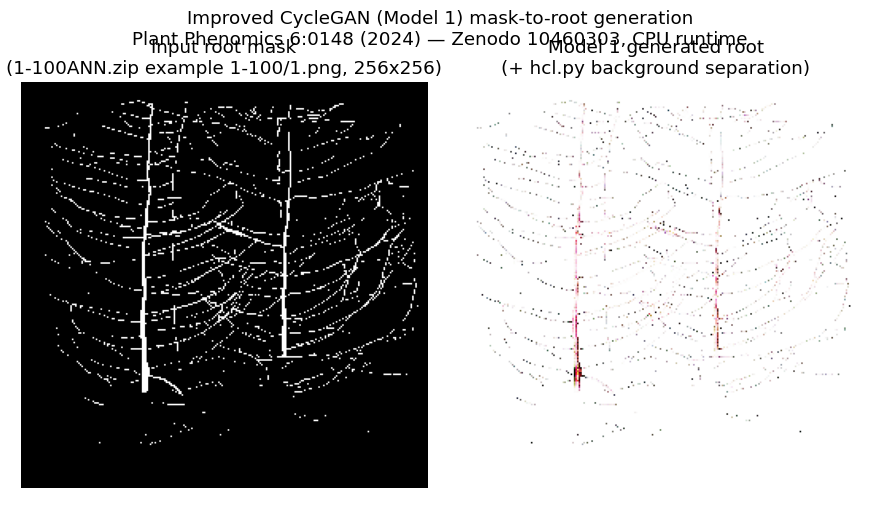

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 4.6))
axes[0].imshow(a, cmap="gray")
axes[0].set_title("Input root mask\n(1-100ANN.zip example 1-100/1.png, 256x256)")
axes[1].imshow(out)
axes[1].set_title("Model 1 generated root\n(+ hcl.py background separation)")
for ax in axes:
    ax.axis("off")
fig.suptitle("Improved CycleGAN (Model 1) mask-to-root generation\nPlant Phenomics 6:0148 (2024) — Zenodo 10460303, CPU runtime")
fig.tight_layout()
fig.savefig("/content/root_generation_result.png", dpi=110)
plt.close(fig)
print("saved /content/root_generation_result.png")
from IPython.display import Image as IPyImage
IPyImage(filename="/content/root_generation_result.png")

**Cell 10: provenance summary.** Print the exact sources, checksums, commit, checkpoint, and device used, for the run record. Expected: a compact JSON-style provenance block.

In [ ]:
print({
    "paper": "Plant Phenomics 6:0148 (2024), DOI 10.34133/plantphenomics.0148, PMCID PMC11020132",
    "code_repo": "https://github.com/jiwd123/improved_cyclegan",
    "code_commit": AUTHOR_COMMIT,
    "weights": "Zenodo 10460303 model.zip md5 " + MODEL_MD5 + " (model1/netG_A2B.pth, model1/netG_B2A.pth)",
    "mask_input": "Zenodo 10460303 1-100ANN.zip md5 " + ANN_MD5 + ", file 1-100/1.png",
    "selected_direction": GEN_NAME,
    "device": DEVICE,
    "generator_params": sum(p.numel() for p in G_A2B.parameters()),
})

{'paper': 'Plant Phenomics 6:0148 (2024), DOI 10.34133/plantphenomics.0148, PMCID PMC11020132', 'code_repo': 'https://github.com/jiwd123/improved_cyclegan', 'code_commit': 'bf8aa4112b77201474953590879d45164c98ccae', 'weights': 'Zenodo 10460303 model.zip md5 839852695d6d9d08b5b70c984c601f2a (model1/netG_A2B.pth, model1/netG_B2A.pth)', 'mask_input': 'Zenodo 10460303 1-100ANN.zip md5 55665de1e1a07389d9ab23df1bd98589, file 1-100/1.png', 'selected_direction': 'netG_A2B', 'device': 'cpu', 'generator_params': 25419195}
